In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Import librerie e configurazione

In [ ]:
from sklearn.model_selection import train_test_split
import os
import shutil
from PIL import Image
from patchify import patchify
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetB3
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils import class_weight

#Parametri che cambiano a seconda del modello e del path del dataset
IMG_SIZE = 224
DATASET_PATH = '/kaggle/input'

2026-05-18 15:19:19.416249: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779117559.962500      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779117560.077308      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779117561.187849      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779117561.187912      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779117561.187915      57 computation_placer.cc:177] computation placer alr

In [ ]:
src = "/kaggle/input/datasets/demianfourier/dataset-split/patched"

# Preparazione dati

In [7]:
# Parametri
BATCH_SIZE  = 32
LR_HEAD     = 1e-3   # fase 1: solo la testa
LR_FINETUNE = 1e-5   # fase 2: fine-tuning
WARMUP_EPOCHS   = 10
FINETUNE_EPOCHS = 20
UNFREEZE_LAST_N = 30
 
#SAVE_PATH = "/kaggle/output"
 
datagen_train = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    vertical_flip=False,
    rotation_range=20,
    brightness_range=[0.8, 1.2],
    zoom_range=0.15,
    fill_mode='nearest'
)
 
# Val e Test non devono avere augmentation, solo preprocessing normalizza l'immaginw
datagen_val = ImageDataGenerator(preprocessing_function=preprocess_input)
datagen_test = ImageDataGenerator(preprocessing_function=preprocess_input)
 
# 3. Generatori
train_gen = datagen_train.flow_from_directory(
    src+"/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)
 
val_gen = datagen_val.flow_from_directory(
    src+"/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)
 
test_gen = datagen_test.flow_from_directory(
    src+"/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 32247 images belonging to 5 classes.
Found 10806 images belonging to 5 classes.
Found 10300 images belonging to 5 classes.


# Architettura ResNet

In [ ]:
#Carico il modello (ResNet50) senza la testa e con i pesi pre-addestrati su ImageNet
base = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False #base.trainable=False blocca tutti i pesi del modello

x   = base.output
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation="relu")(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(5, activation="softmax")(x)

model = Model(inputs=base.input, outputs=out) 
#con Model definiamo il modello specificando che come input prende lo stesso input di ResNet50 e come output restituisce out che 
#come è stato definito è un layer con 5 neuroni (uno per classe)

#model.compile() compila il modello, in questo caso come ottimizzatore usiamo Adam con un LR alto perché stiamo addestramento solo la testa che parte con pesi casuali
model.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1779117787.819600      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779117787.825715      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# train_gen.classes restituisce un array con le etichette di classe 
y_train = train_gen.classes
 
# Calcoliamo i pesi con la formula "balanced" (quella del paper)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
 
# Trasformiamo in dizionario: {indice_classe: valore_peso}
class_weights_dict = dict(enumerate(weights))
 
print("Pesi applicati alle classi:")
for idx, weight in class_weights_dict.items():
    class_name = list(train_gen.class_indices.keys())[list(train_gen.class_indices.values()).index(idx)]
    print(f"Classe {idx} ({class_name}): {weight:.4f}")

Pesi applicati alle classi:
Classe 0 (Durer): 0.9198
Classe 1 (Edgar_Degas): 0.6731
Classe 2 (Pablo_Picasso): 2.7550
Classe 3 (Pierre-Auguste_Renoir): 1.7044
Classe 4 (Vincent_van_Gogh): 0.6769


In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="/kaggle/working/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]
"""
callbacks è una lista di funzioni chiamate durante l'addestramento, in questo caso abbiamo mess:
1. EarlyStopping: interrompe prematuramente se dopo 5 epoche (patience=5) la loss di val non migliora e torno ai pesi di prima
2. ReduceLROnPlateau: diminuisce di un fattore 0.2 il LR se dopo 3 epoche (patience=3) la loss val non migliora
3. ModelCheckpoint: salva nel filepath specificato il miglior modello in base al monitor (val_accuracy). Verbose=1 per stampa di qunado lo fa
"""

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
#Warm-up: addestramento della testa e gli altri pesi congelati
print("\nInizio WARM-UP...")
history_warmup = model.fit(
    train_gen,
    epochs=WARMUP_EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights_dict,  # Applicazione pesi
    callbacks=callbacks
)
# Addestriamo solo i nuovi livelli finali
history_phase1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)


Inizio WARM-UP...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.7228 - loss: 0.7736
Epoch 1: val_accuracy improved from -inf to 0.79012, saving model to /kaggle/working/best_model.keras
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 856s 840ms/step - accuracy: 0.7228 - loss: 0.7734 - val_accuracy: 0.7901 - val_loss: 0.5583 - learning_rate: 0.0010
Epoch 2/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.8243 - loss: 0.4662
Epoch 2: val_accuracy improved from 0.79012 to 0.83463, saving model to /kaggle/working/best_model.keras
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 501s 497ms/step - accuracy: 0.8243 - loss: 0.4661 - val_accuracy: 0.8346 - val_loss: 0.4541 - learning_rate: 0.0010
Epoch 3/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8463 - loss: 0.4024
Epoch 3: val_accuracy did not improve from 0.83463
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 532s 527ms/step - accuracy: 0.8463 - loss: 0.4024 - val_accuracy: 0.8282 - val_loss: 0.4927 - learning_rate: 0.0010
Epoch 4/10
1008/1008 ━━━━━━━━━━

In [12]:
base.trainable = True
for layer in base.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False
 
model.compile(
    optimizer=Adam(learning_rate=LR_FINETUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
print("\nInizio FINE-TUNING...")
history_finetune = model.fit(
    train_gen,
    epochs=FINETUNE_EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights_dict,  # Applicazione pesi anche qui
    callbacks=callbacks,
)


Inizio FINE-TUNING...
Epoch 1/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.8009 - loss: 0.5187
Epoch 1: val_accuracy improved from -inf to 0.82741, saving model to /kaggle/working/best_model.keras
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 671s 646ms/step - accuracy: 0.8009 - loss: 0.5187 - val_accuracy: 0.8274 - val_loss: 0.4763 - learning_rate: 1.0000e-05
Epoch 2/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8563 - loss: 0.3856
Epoch 2: val_accuracy improved from 0.82741 to 0.84564, saving model to /kaggle/working/best_model.keras
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 572s 567ms/step - accuracy: 0.8563 - loss: 0.3856 - val_accuracy: 0.8456 - val_loss: 0.4420 - learning_rate: 1.0000e-05
Epoch 3/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8873 - loss: 0.3038
Epoch 3: val_accuracy improved from 0.84564 to 0.85878, saving model to /kaggle/working/best_model.keras
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 582s 578ms/step - accuracy: 0.8873 - loss: 0.3038 - val_accura

Caricamento del modello migliore e valutazione sul set di test...
Found 10300 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


322/322 ━━━━━━━━━━━━━━━━━━━━ 38s 101ms/step - accuracy: 0.9091 - loss: 0.3349

Test Loss: 0.5113
Test Accuracy: 0.8565

Generazione delle previsioni per la Confusion Matrix...
322/322 ━━━━━━━━━━━━━━━━━━━━ 37s 102ms/step


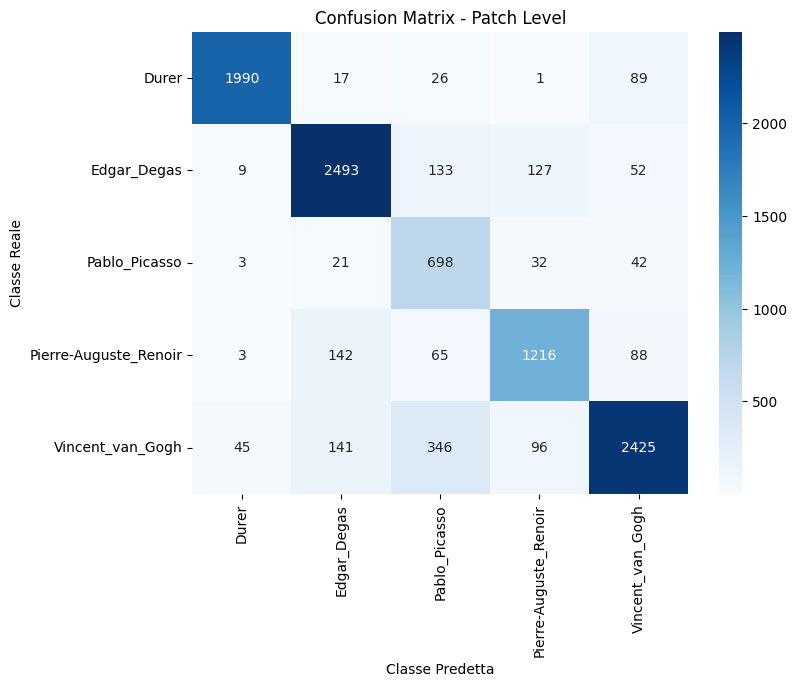


Classification Report:
                       precision    recall  f1-score   support

                Durer       0.97      0.94      0.95      2123
          Edgar_Degas       0.89      0.89      0.89      2814
        Pablo_Picasso       0.55      0.88      0.68       796
Pierre-Auguste_Renoir       0.83      0.80      0.81      1514
     Vincent_van_Gogh       0.90      0.79      0.84      3053

             accuracy                           0.86     10300
            macro avg       0.83      0.86      0.83     10300
         weighted avg       0.87      0.86      0.86     10300



In [ ]:
print('Caricamento del modello migliore e valutazione sul set di test...')
SAVE_PATH = "/kaggle/working/best_model.keras"
# 1. Carica il modello migliore
model_best = keras.models.load_model(SAVE_PATH)

datagen_test = ImageDataGenerator(preprocessing_function=preprocess_input)

#data_test.flow_from_directory restituisce un generatore con le caratteristiche indicate
test_gen = datagen_test.flow_from_directory(
    src+"/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# 2. Valutazione del modello sul set di test
loss, accuracy = model_best.evaluate(test_gen)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


# 3. stampa la predizione per ogni immagine del test set
print("\nGenerazione delle previsioni per la Confusion Matrix...")
predictions = model_best.predict(test_gen)

# 4. Converto le probabilità in indici di classe (es. [0.1, 0.9] -> 1)
y_pred = np.argmax(predictions, axis=1)

# 5. Ottiengo le etichette reali dal generatore
y_true = test_gen.classes

# 6. Calcolo la Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_gen.class_indices.keys()) # ["NVG", "VG"]

# 7. Visualizzazione Grafica
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Patch Level')
plt.ylabel('Classe Reale')
plt.xlabel('Classe Predetta')
plt.show()

# 8. Report testuale (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


--- INIZIO CONFRONTO METODI DI AGGREGAZIONE (MULTI-CLASSE) ---
322/322 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step

--- TABELLA ACCURATEZZA QUADRO-LEVEL ---
            Metodo  Accuratezza
   Majority Voting     0.856505
  Simple Averaging     0.856505
       Max Pooling     0.856505
Weighted Averaging     0.856505


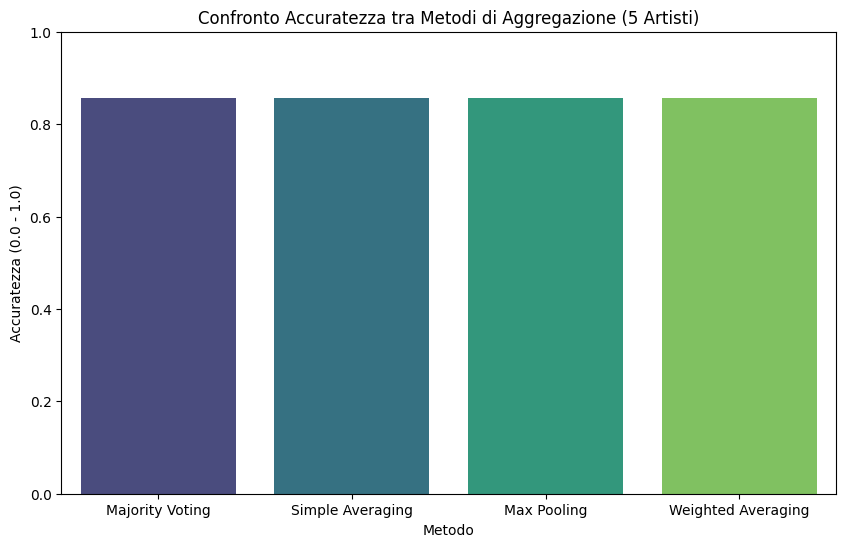

In [ ]:
"""
In questa sezione, visto che abbiamo usato come meetodo di data augmentation il patching, il modello lavorerà su patch
224x224 e per ottenere una predizione su un quadro intero bisogna aggregare le predizioni delle singole patch. 
Qua abbiamo confrontato vari metodi di aggregazione, e come si vede alla fine, sono tutti molto buoni per questo task. 
"""
print("\n--- INIZIO CONFRONTO METODI DI AGGREGAZIONE (MULTI-CLASSE) ---")

# 1. Generiamo la matrice completa delle probabilità [Numero Patch x 5 Classi]
probs = model_best.predict(test_gen)

# 2. Creiamo il DataFrame base accoppiando le informazioni dei patch
df_patches = pd.DataFrame({
    'filename': test_gen.filenames,
    'pred_patch': np.argmax(probs, axis=1),
    'label_reale': test_gen.classes
})

#Isoliamo il nome del quadro puro eliminando la stringa del patch (es. _patch_0)
df_patches['nome_quadro'] = df_patches['filename'].apply(lambda x: x.split('/')[-1].split('_patch')[0])

# Creiamo le colonne per le probabilità di ciascuna delle 5 classi
nomi_colonne_prob = [f'prob_classe_{i}' for i in range(5)]
df_probs = pd.DataFrame(probs, columns=nomi_colonne_prob)

# Uniamo i metadati dei patch con la loro matrice di probabilità Softmax
df_final = pd.concat([df_patches, df_probs], axis=1)

"""==========================================
   ESECUZIONE DEI 4 METODI DI AGGREGAZIONE
=========================================="""

# Metodo 1: Majority Voting (Voto di Maggioranza puro sulla classe predetta)
maj_vote = df_final.groupby('nome_quadro').agg({
    'pred_patch': lambda x: x.value_counts().index[0],
    'label_reale': 'first'
})

# Metodo 2: Simple Averaging (Media aritmetica delle probabilità Softmax)
avg_prob_df = df_final.groupby('nome_quadro')[nomi_colonne_prob].mean()
avg_prob_df['pred'] = np.argmax(avg_prob_df.values, axis=1)
avg_prob_df['label_reale'] = df_final.groupby('nome_quadro')['label_reale'].first()

# Metodo 3: Max Pooling (Assegnazione in base alla massima confidenza locale trovata)
max_pool_df = df_final.groupby('nome_quadro')[nomi_colonne_prob].max()
max_pool_df['pred'] = np.argmax(max_pool_df.values, axis=1)
max_pool_df['label_reale'] = df_final.groupby('nome_quadro')['label_reale'].first()

# Metodo 4: Weighted Averaging (Media pesata in base alla stabilità della predizione)
def calcola_media_pesata(group):
    matrice_prob = group[nomi_colonne_prob].values  # Matrice [N_patch x 5]
    # Più la probabilità massima si distacca dall'incertezza (1/5 = 0.2), più il patch è sicuro
    pesi = np.max(matrice_prob, axis=1) - 0.2
    pesi = np.maximum(pesi, 1e-5)  # Evita divisioni matematiche per zero
    media_pesata = np.average(matrice_prob, axis=0, weights=pesi)
    return pd.Series(media_pesata, index=nomi_colonne_prob)

# Calcoliamo la media pesata escludendo la colonna di raggruppamento per evitare i warning
w_avg_df = df_final.groupby('nome_quadro').apply(calcola_media_pesata, include_groups=False)
w_avg_df['pred'] = np.argmax(w_avg_df[nomi_colonne_prob].values, axis=1)
w_avg_df['label_reale'] = df_final.groupby('nome_quadro')['label_reale'].first()

"""==========================================
   GENERAZIONE TABELLA DI CONFRONTO E GRAFICO
=========================================="""
risultati = {
    "Metodo": ["Majority Voting", "Simple Averaging", "Max Pooling", "Weighted Averaging"],
    "Accuratezza": [
        accuracy_score(maj_vote['label_reale'], maj_vote['pred_patch']),
        accuracy_score(avg_prob_df['label_reale'], avg_prob_df['pred']),
        accuracy_score(max_pool_df['label_reale'], max_pool_df['pred']),
        accuracy_score(w_avg_df['label_reale'], w_avg_df['pred'])
    ]
}

df_confronto = pd.DataFrame(risultati)
print("\n--- TABELLA ACCURATEZZA QUADRO-LEVEL ---")
print(df_confronto.to_string(index=False))

# Generazione del grafico
plt.figure(figsize=(10, 6))
sns.barplot(x='Metodo', y='Accuratezza', data=df_confronto, hue='Metodo', palette='viridis', legend=False)
plt.ylim(0.0, 1.0)
plt.title('Confronto Accuratezza tra Metodi di Aggregazione (5 Artisti)')
plt.ylabel('Accuratezza (0.0 - 1.0)')
plt.show()